In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

Data prep and processing

In [3]:
import pandas as pd

def make_melanoma_binary_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["diagnosis"] = df["diagnosis"].replace(
        {
            "seborrheic keratosis": "BKL",
            "lichenoid keratosis": "BKL",
            "solar lentigo": "BKL",
            "lentigo NOS": "BKL",
            "cafe-au-lait macule": "unknown",
            "atypical melanocytic proliferation": "unknown",
        }
    )

    return pd.DataFrame(
        {
            "image_id": df["image_name"].astype(str),
            "target": (df["diagnosis"].astype(str) == "melanoma").astype(int),
        }
    )

In [4]:
milk10k_df = pd.read_csv('inference_results/infer=milk10k_model=finetune_mskcc_blur0.csv')

In [5]:
gt = pd.read_csv('inference_data/milk10k/MILK10k_Training_GroundTruth.csv', index_col=False)
meta = pd.read_csv('inference_data/milk10k/MILK10k_Training_Metadata.csv', index_col=False)

# robustly find lesion_id columns
lesion_col_gt = next((c for c in gt.columns if c.strip().lower() == 'lesion_id'), gt.columns[0])
lesion_col_meta = next((c for c in meta.columns if c.strip().lower() == 'lesion_id'), meta.columns[0])

# find MEL column (case-insensitive); prefer exact 'mel' then any column containing 'mel'
mel_col = next((c for c in gt.columns if c.strip().lower() == 'mel'), None)
if mel_col is None:
    mel_candidates = [c for c in gt.columns if 'mel' in c.strip().lower()]
    if not mel_candidates:
        raise KeyError("No MEL column found in ground truth CSV")
    mel_col = mel_candidates[0]

# merge ground-truth with metadata to get isic_id mapping
merged = gt[[lesion_col_gt, mel_col]].merge(
    meta[[lesion_col_meta, 'isic_id']].rename(columns={lesion_col_meta: lesion_col_gt}),
    on=lesion_col_gt,
    how='left'
)

# image_name prefer isic_id from metadata, else lesion_id; target is 1 when MEL==1
df_milk10k_targets = pd.DataFrame({
    'image_name': merged['isic_id'].fillna(merged[lesion_col_gt]).astype(str),
    'target': (pd.to_numeric(merged[mel_col], errors='coerce') == 1).astype(int)
})

df_milk10k_targets.head()

,image_name,target
0,ISIC_8149219,0
1,ISIC_4671410,0
2,ISIC_3904045,0
3,ISIC_5371928,0
4,ISIC_0791494,0


In [6]:
# only keep those image_names for which the metadata image_type is dermoscopic
meta_dermoscopic = meta[meta['image_type'] == 'dermoscopic']
df_milk10k_targets = df_milk10k_targets[df_milk10k_targets['image_name'].isin(meta_dermoscopic['isic_id'].astype(str))]
print(f'MILK10k dermoscopic images: {len(df_milk10k_targets)}')
df_milk10k_targets.head()

MILK10k dermoscopic images: 5240


,image_name,target
1,ISIC_4671410,0
3,ISIC_5371928,0
5,ISIC_3624913,0
7,ISIC_5186409,0
9,ISIC_1048297,0


In [7]:
# merge df_milk10k_targets with milk10k_df with milk10k_adae
milk10k_adae = pd.read_csv('../adae/subs/MILK10k_Training_Metadata/sub_allfolds_average.csv')
# rename target to pred
milk10k_adae = milk10k_adae.rename(columns={'target': 'pred'})
milk10k_adae.head()

# merge df_milk10k_targets and milk10k_adae on image_name
merged_milk10k = df_milk10k_targets.merge(milk10k_adae, on='image_name')
merged_milk10k.head()

,image_name,target,pred
0,ISIC_4671410,0,0.519520
1,ISIC_5371928,0,0.000009
2,ISIC_3624913,0,0.038339
3,ISIC_5186409,0,0.006655
4,ISIC_1048297,0,0.025488


In [8]:
milk10k_fp_df = pd.read_csv('inference_results/infer=milk10k_model=finetune_mskcc_blur0.csv')
milk10k_fp_df['fp_pred'] = milk10k_fp_df[['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']].mode(axis=1)[0]
milk10k_fp_df['image_name'] = milk10k_fp_df['file'].str.split('/').str[-1].str.replace('.jpg', '', regex=False)
milk10k_fp_df = milk10k_fp_df[['image_name', 'fp_pred']]

# merge
milk10k_final_df = merged_milk10k.merge(milk10k_fp_df, on='image_name')
milk10k_final_df.head()

,image_name,target,pred,fp_pred
0,ISIC_4671410,0,0.519520,1.0
1,ISIC_5371928,0,0.000009,1.0
2,ISIC_3624913,0,0.038339,2.0
3,ISIC_5186409,0,0.006655,2.0
4,ISIC_1048297,0,0.025488,1.0


In [9]:
isic_2020_adae = pd.read_csv('../adae/subs/challenge-2020-test_metadata_2026-01-14/sub_allfolds_average.csv')
isic_2020_adae = isic_2020_adae.rename(columns={'target': 'pred'})

gt_csv = 'inference_data/isic2020_test/challenge-2020-test_metadata_2026-01-14.csv'
gt_df = pd.read_csv(gt_csv)
gt_df = gt_df[['isic_id', 'diagnosis_1']]
gt_df = gt_df.rename(columns={'isic_id': 'image_name'})
gt_df['target'] = (gt_df['diagnosis_1'] == 'Malignant').astype(int)

# add target column to isic_2020_adae
isic_2020_final_df = isic_2020_adae.merge(gt_df[['image_name', 'target']], on='image_name')

# skin colors df
skin_colors_csv = 'inference_results/infer=isic2020_test_model=finetune_mskcc_blur0.csv'
skin_colors_df = pd.read_csv(skin_colors_csv)

# voting fold_0 ... fold_4 columns with values 1-6
skin_colors_df['fp_pred'] = skin_colors_df[['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']].mode(axis=1)[0]
skin_colors_df['image_name'] = skin_colors_df['file'].str.split('/').str[-1].str.replace('.jpg', '', regex=False)

# add fp_pred to isic_2020_final_df
isic_2020_final_df = isic_2020_final_df.merge(skin_colors_df[['image_name', 'fp_pred']], on='image_name', how='left')
display(isic_2020_final_df.head())


,image_name,pred,target,fp_pred
0,ISIC_0052060,0.000034,0,1
1,ISIC_0052349,0.000170,0,1
2,ISIC_0058510,0.000429,0,1
3,ISIC_0073313,0.000125,0,1
4,ISIC_0073502,0.000585,0,2


In [10]:
# combine milk10k_final_df and isic_2020_final_df
combined_df = pd.concat([milk10k_final_df, isic_2020_final_df], ignore_index=True)

In [11]:
# add ITA predictions
milk10k_ita_df = pd.read_csv('inference_results/infer=milk10k_model=finetune_mskcc_blur0_lab_lab.csv')
isic2020_ita_df = pd.read_csv('inference_results/infer=isic2020_test_model=finetune_mskcc_blur0_lab_lab.csv')
ita_df = pd.concat([milk10k_ita_df, isic2020_ita_df], ignore_index=True)
ita_df['image_name'] = ita_df['file'].str.split('/').str[-1].str.replace('.jpg', '', regex=False)

# mean L, a, b columns per fold
ita_df['L_mean'] = ita_df[['L_fold_0', 'L_fold_1', 'L_fold_2', 'L_fold_3', 'L_fold_4']].mean(axis=1)
ita_df['a_mean'] = ita_df[['a_fold_0', 'a_fold_1', 'a_fold_2', 'a_fold_3', 'a_fold_4']].mean(axis=1)
ita_df['b_mean'] = ita_df[['b_fold_0', 'b_fold_1', 'b_fold_2', 'b_fold_3', 'b_fold_4']].mean(axis=1)

# calculate ITA
ita_df['ITA_pred'] = np.degrees(np.arctan2((ita_df['L_mean'] - 50), ita_df['b_mean']))

# add ITA_pred to combined_df
combined_df = combined_df.merge(ita_df[['image_name', 'ITA_pred']], on='image_name', how='left')
display(combined_df.head())


,image_name,target,pred,fp_pred,ITA_pred
0,ISIC_4671410,0,0.519520,1.0,8.635166
1,ISIC_5371928,0,0.000009,1.0,45.639779
2,ISIC_3624913,0,0.038339,2.0,34.475179
3,ISIC_5186409,0,0.006655,2.0,12.171621
4,ISIC_1048297,0,0.025488,1.0,43.995047


EDA

In [12]:
# Distribution of Fitzpatrick types
print("Fitzpatrick type distribution in combined dataset:")
print(combined_df['fp_pred'].value_counts().sort_index())

Fitzpatrick type distribution in combined dataset:
fp_pred
0.0     124
1.0    9182
2.0    5714
3.0    1069
4.0     125
5.0       8
Name: count, dtype: int64


In [13]:
# distribution of GT malignancy per FP type
print("\nDistribution of GT malignancy per Fitzpatrick type:")
fp_malignancy_dist = combined_df.groupby('fp_pred')['target'].value_counts(normalize=True).unstack(fill_value=0)
print(fp_malignancy_dist)


Distribution of GT malignancy per Fitzpatrick type:
target          0         1
fp_pred                    
0.0      0.951613  0.048387
1.0      0.958506  0.041494
2.0      0.958173  0.041827
3.0      0.940131  0.059869
4.0      0.856000  0.144000
5.0      0.500000  0.500000


In [14]:
# auroc by fp_pred
from scipy.stats import bootstrap

def patient_bootstrap_mean_ci(
    df: pd.DataFrame,
    value_col: str,
    patient_col: str = "patient_id",
    *,
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # or "BCa"
    random_state: int = 0,
):
    """
    Patient-level (cluster) bootstrap CI for the MEAN of a per-row metric
    (e.g., Delta E computed per image/lesion/site).

    Resamples patients with replacement; includes all rows for each sampled patient.
    """
    d = df[[patient_col, value_col]].dropna().copy()
    vals_by_patient = []
    patient_ids = []

    for pid, sub in d.groupby(patient_col, sort=False):
        patient_ids.append(pid)
        vals_by_patient.append(sub[value_col].to_numpy(dtype=float, copy=False))

    patient_ids = np.array(patient_ids)
    if patient_ids.size < 2:
        raise ValueError("Need at least 2 patients for a patient-level bootstrap.")

    # Point estimate: mean over all rows once
    point_est = float(d[value_col].to_numpy(dtype=float, copy=False).mean())

    # Fast lookup dict
    grouped = {pid: v for pid, v in zip(patient_ids, vals_by_patient)}

    def stat(resampled_patient_ids, axis=-1):
        ids = np.asarray(resampled_patient_ids)
        parts = [grouped[pid] for pid in ids]  # patients can repeat
        x = np.concatenate(parts, axis=0)
        return float(np.mean(x))

    res = bootstrap(
        data=(patient_ids,),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=np.random.default_rng(random_state),
    )

    return {
        "mean": point_est,
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_ids.size),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

def bootstrap_auroc_ci(
    df: pd.DataFrame,
    target_col: str,
    pred_col: str,
    patient_col: str = "patient_id",
    *,
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # "BCa" also works
    random_state: int = 0,
):
    """
    Patient-level STRATIFIED (cluster) bootstrap CI for AUROC.

    Stratification is done at the patient level:
      - a patient is "positive" if any row for that patient has target==1
      - resample positive patients and negative patients separately (with replacement)
      - include all rows for each sampled patient
    """
    d = df[[patient_col, target_col, pred_col]].dropna().copy()
    d[target_col] = d[target_col].astype(int)
    d[pred_col] = pd.to_numeric(d[pred_col], errors="coerce")
    d = d.dropna(subset=[pred_col])

    # Patient-level label for stratification
    patient_y = d.groupby(patient_col, sort=False)[target_col].max().astype(int)
    pos_patients = patient_y[patient_y == 1].index.to_numpy()
    neg_patients = patient_y[patient_y == 0].index.to_numpy()

    if pos_patients.size == 0 or neg_patients.size == 0:
        raise ValueError("Need at least one positive and one negative patient for AUROC.")

    # Pre-split data by patient for fast lookup
    grouped = {}
    for pid, sub in d.groupby(patient_col, sort=False):
        grouped[pid] = sub[[target_col, pred_col]].to_numpy(dtype=float, copy=False)

    # Point estimate on all rows once
    from sklearn.metrics import roc_auc_score
    point_est = float(roc_auc_score(d[target_col].to_numpy(), d[pred_col].to_numpy()))

    n_pos = pos_patients.size
    n_neg = neg_patients.size

    def stat(resampled_ids_pos, resampled_ids_neg, axis=-1):
        ids_pos = np.asarray(resampled_ids_pos)
        ids_neg = np.asarray(resampled_ids_neg)
        ids = np.concatenate([ids_pos, ids_neg], axis=0)

        parts = [grouped[pid] for pid in ids]  # patients can repeat
        x = np.concatenate(parts, axis=0)
        return float(roc_auc_score(x[:, 0], x[:, 1]))

    rng = np.random.default_rng(random_state)
    res = bootstrap(
        data=(pos_patients, neg_patients),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=rng,
    )

    return {
        "auroc": point_est,
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_y.shape[0]),
        "n_patients_pos": int(n_pos),
        "n_patients_neg": int(n_neg),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

In [15]:
for fp_type in range(0, 6):
    sub_df = combined_df[combined_df['fp_pred'] == fp_type]
    if len(sub_df) < 10:
        print(f"FP type {fp_type}: Not enough data ({len(sub_df)} samples), skipping AUROC calculation.")
        continue
    try:
        auroc_res = bootstrap_auroc_ci(
            sub_df,
            target_col='target',
            pred_col='pred',
            patient_col='image_name',  # assuming image_name is unique per patient
            n_resamples=2000,
            confidence_level=0.95,
            method='percentile',
            random_state=42,
        )
        print(f"FP type {fp_type}: AUROC = {auroc_res['auroc']:.4f} (95% CI: {auroc_res['ci_low']:.4f} - {auroc_res['ci_high']:.4f})")
    except ValueError as e:
        print(f"FP type {fp_type}: Error calculating AUROC - {e}")

FP type 0: AUROC = 0.9463 (95% CI: 0.8757 - 0.9972)
FP type 1: AUROC = 0.9313 (95% CI: 0.9172 - 0.9442)
FP type 2: AUROC = 0.9211 (95% CI: 0.8973 - 0.9404)
FP type 3: AUROC = 0.9486 (95% CI: 0.9132 - 0.9801)
FP type 4: AUROC = 0.9709 (95% CI: 0.9340 - 0.9959)
FP type 5: Not enough data (8 samples), skipping AUROC calculation.


In [16]:
# forest plot of above
fp_types = []
auroc_means = []
auroc_ci_lows = []
auroc_ci_highs = []

for fp_type in range(0, 6):
    sub_df = combined_df[combined_df['fp_pred'] == fp_type]
    if len(sub_df) < 10:
        continue
    try:
        auroc_res = bootstrap_auroc_ci(
            sub_df,
            target_col='target',
            pred_col='pred',
            patient_col='image_name',
            n_resamples=2000,
            confidence_level=0.95,
            method='percentile',
            random_state=42,
        )
        fp_types.append(fp_type)
        auroc_means.append(auroc_res['auroc'])
        auroc_ci_lows.append(auroc_res['ci_low'])
        auroc_ci_highs.append(auroc_res['ci_high'])
    except ValueError:
        continue

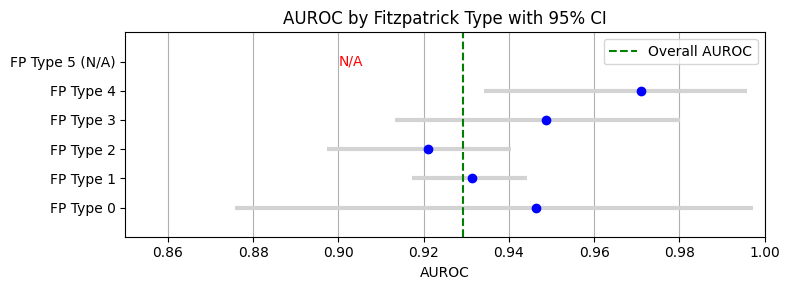

In [17]:
# Plot with FP type 6 as N/A
from sklearn.metrics import roc_auc_score


plt.figure(figsize=(8, 3))
y_pos = np.arange(len(fp_types) + 1)  # +1 for FP type 6 which is N/A
auroc_errors = [np.array(auroc_means) - np.array(auroc_ci_lows), np.array(auroc_ci_highs) - np.array(auroc_means)]
plt.errorbar(auroc_means, y_pos[:-1], xerr=auroc_errors, fmt='o', color='blue', ecolor='lightgray', elinewidth=3, capsize=0)
plt.yticks(y_pos, [f'FP Type {fp}' for fp in fp_types] + ['FP Type 5 (N/A)'])
plt.xlabel('AUROC')
plt.title('AUROC by Fitzpatrick Type with 95% CI')
plt.xlim(0.85, 1.0)
plt.ylim(-1, len(fp_types) + 1)
plt.grid(axis='x')

# Place N/A for FP type 6 25% away from the right edge
plt.text(0.9, len(fp_types), 'N/A', va='center', fontsize=10, color='red')

# add overall AUROC
overall_auroc = roc_auc_score(combined_df['target'], combined_df['pred'])
plt.axvline(overall_auroc, color='green', linestyle='--', label='Overall AUROC')
plt.legend()

plt.tight_layout()
plt.show()

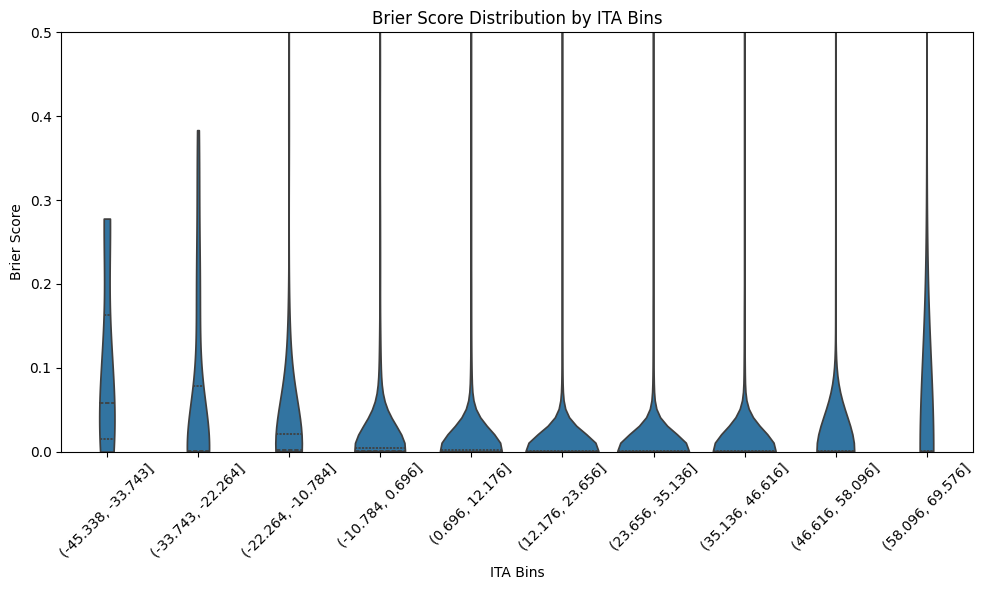

In [23]:
# logistic regression ITA vs. Brier score of predictions
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
import statsmodels.api as sm

# drop rows with NaN ITA_pred
df_ita_brier = combined_df.dropna(subset=['ITA_pred']).copy()
df_ita_brier['brier_score'] = (df_ita_brier['pred'] - df_ita_brier['target']) ** 2

# violin plot, binned ita
df_ita_brier['ITA_bin'] = pd.cut(df_ita_brier['ITA_pred'], bins=10)
plt.figure(figsize=(10, 6))
sns.violinplot(x='ITA_bin', y='brier_score', data=df_ita_brier, inner='quartile', cut=0)
plt.ylim(0, 0.5)
plt.xticks(rotation=45)
plt.title('Brier Score Distribution by ITA Bins')
plt.xlabel('ITA Bins')
plt.ylabel('Brier Score')
plt.tight_layout()
plt.show()

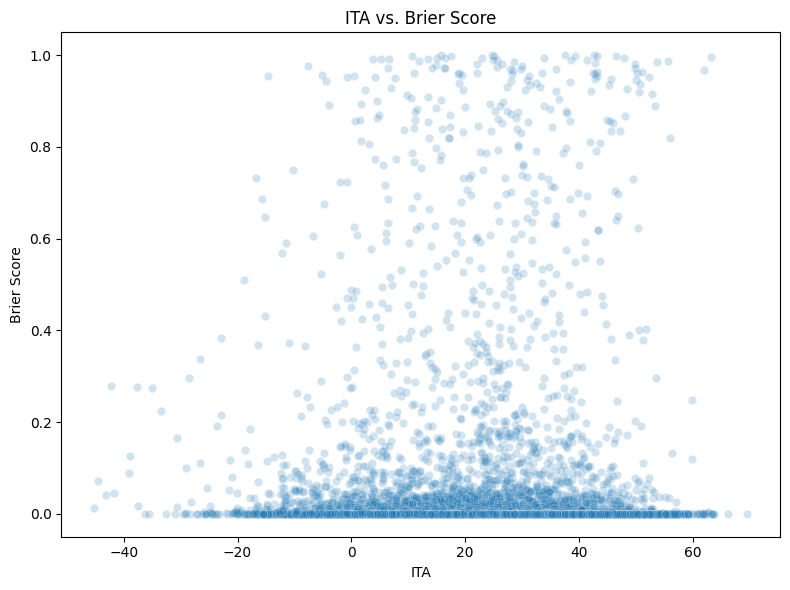

In [28]:
# scatterplot ita vs brier score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ITA_pred', y='brier_score', data=df_ita_brier, alpha=0.2)
plt.title('ITA vs. Brier Score')
plt.xlabel('ITA')
plt.ylabel('Brier Score')
plt.tight_layout()
plt.show()